In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import cartopy
import cartopy.crs as ccrs
import tqdm
# import pickle

ATL07 Data Dictionary

https://nsidc.org/sites/default/files/atl0720product20data20dictionary_0.pdf

In [2]:
ddir='/home/robbie/Dropbox/algae/is2_atl07/'

files = os.listdir(ddir)
files = sorted([f for f in files if (('.h5' in f) or ('.h5' in f))])
len(files)

279

# Make a plot for visualisation

In [3]:
dfs = []

for f in files:
    try:
        with h5py.File(f'{ddir}{f}', "r") as f:

            beams = ['r','l']

            for beamside in beams:
            
                data = f[f'gt1{beamside}']
            
                lon=np.array(data['sea_ice_segments']['longitude'])[::50]
                lat=np.array(data['sea_ice_segments']['latitude'])[::50]
            
                df = pd.DataFrame({'lon':lon,'lat':lat})
    
                dfs.append(df)
    except Exception as e:
        print(e)

master_df = pd.concat(dfs)

# pickle.dump(master_df,open('/home/robbie/Dropbox/algae/track_coords.p','wb'))

master_df.to_csv('track_coords.csv')

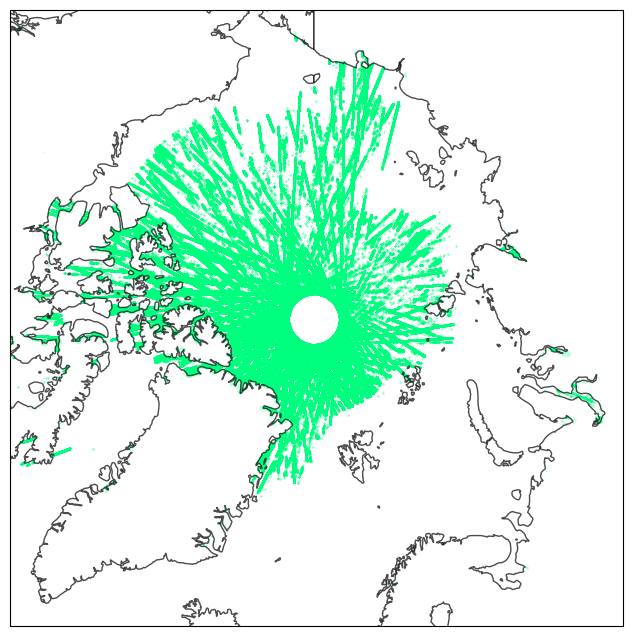

In [5]:
fig = plt.figure(figsize=(8,8))
proj = ccrs.NorthPolarStereo()
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, 90, 66], ccrs.PlateCarree())
ax.add_feature(cartopy.feature.LAND, edgecolor='black',zorder=1,alpha=0.7,facecolor='white')

m = ax.scatter(master_df['lon'],
                  master_df['lat'],
                 transform=ccrs.PlateCarree(),
                  zorder=0,
               color='springgreen',s=0.1,
                 )

In [6]:
step_length = 10_000
thresh=0.2
q=0
frac_dfs=[]
        
for f in tqdm.tqdm(files):
    
    with h5py.File(f'{ddir}{f}', "r") as f:
    
        sc_orient = f['orbit_info']['sc_orient'][0]
        if sc_orient==1: beam_side='r' #spacecraft facing forward, strong beam on right
        elif sc_orient==0: beam_side='l' #spacecraft facing backward, strong beam on left

        for beam_no in [1,2,3]:
            
            data = f[f'gt{beam_no}{beam_side}']
        
            s_type = np.array(data['sea_ice_segments']['heights']['height_segment_type'][::1])
            seg_l = np.array(data['sea_ice_segments']['heights']['height_segment_length_seg'][::1])
            hist_w = np.array(data['sea_ice_segments']['stats']['hist_w'][::1])
            lon=np.array(data['sea_ice_segments']['longitude'])[::1]
            lat=np.array(data['sea_ice_segments']['latitude'])[::1]
        
            df = pd.DataFrame({'type':s_type,'seg_length':seg_l,'hist_width':hist_w,'lon':lon,'lat':lat})
        
            df['along_track']=np.cumsum(df['seg_length'])
    
            ### Analyse Steps ###
            
            valid_steps = []
            
            for i in np.arange(step_length,np.max(df['along_track']),step_length):
                
                segs_in_step = df[(df['along_track']<i)&(df['along_track']>i-step_length)]
            
                valid_segs_in_step = segs_in_step[segs_in_step['type']==1]
            
                if valid_segs_in_step.shape[0]>5:
            
                    valid_steps.append(valid_segs_in_step)
    
            lons,lats,frac_r=[],[],[]
            
            for i in np.arange(len(valid_steps)):
            
                df = valid_steps[i]

                df = df[df['seg_length']<30]
                df = df[df['hist_width']<5.4]
            
                if df.shape[0]>10:

                    ridged = df[df['hist_width']>thresh]
                    smooth = df[df['hist_width']<=thresh]
                    len_ridged = np.sum(ridged['seg_length'])
                    len_smooth = np.sum(smooth['seg_length'])
                
                    frac_ridged = len_ridged/(len_ridged+len_smooth)
                
                    lons.append(df['lon'].iloc[0])
                    lats.append(df['lat'].iloc[0])
                    frac_r.append(frac_ridged)
            
            fractions = pd.DataFrame({'lon':lons,'lat':lats,'frac':frac_r})
    
            frac_dfs.append(fractions)


    
frac_df = pd.concat(frac_dfs)

100%|█████████████████████████████████████████| 279/279 [05:11<00:00,  1.12s/it]


In [7]:
frac_df.to_hdf('../aux_data/ridged_fraction.h5',key='rf')

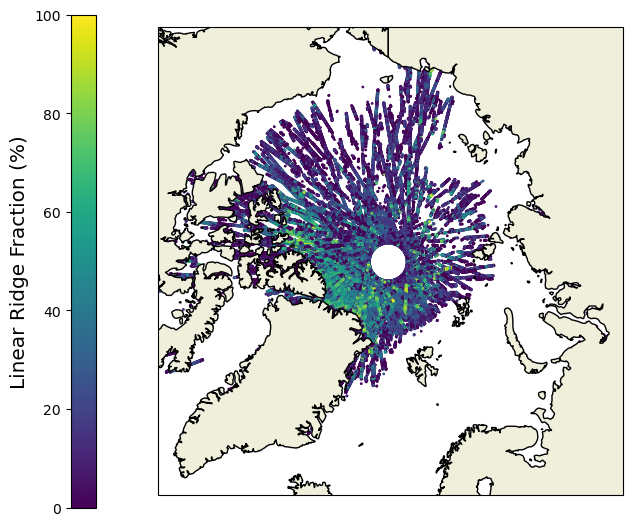

In [9]:
fig = plt.figure(figsize=(8,8))
proj = ccrs.NorthPolarStereo()
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, 90, 66], ccrs.PlateCarree())
ax.add_feature(cartopy.feature.LAND, edgecolor='black',zorder=1,alpha=1)

m = ax.scatter(frac_df['lon'],
               frac_df['lat'],
               c=100*frac_df['frac'],
               vmin=0,vmax=100,
                 transform=ccrs.PlateCarree(),
                  zorder=0,
               s=1,
                 )
cb = fig.colorbar(m,shrink=0.8,location='left')
cb.set_label('Linear Ridge Fraction (%)',fontsize='x-large')

In [44]:
df_si = df[df['type']==1]
df_si.shape

np.sum(df['seg_length']),np.sum(df_si['seg_length'])

(np.float32(3.0793688e+06), np.float32(2.6966848e+06))

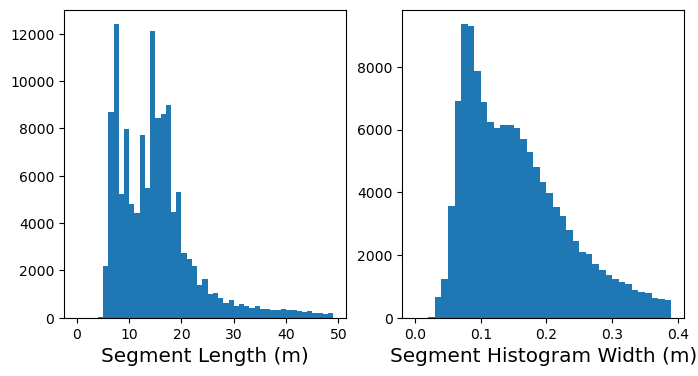

In [10]:
hist_w[hist_w>4]=np.nan

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(8,4))

ax1.hist(seg_l,bins=np.arange(0,50,1))
ax1.set_xlabel('Segment Length (m)',fontsize='x-large')

ax2.hist(hist_w,bins=np.arange(0,0.4,0.01))
ax2.set_xlabel('Segment Histogram Width (m)',fontsize='x-large')
plt.show()

In [17]:
data

<Closed HDF5 group>